# Experiment: MOSTA Brain Gene Review

Objective:
- Review the generated Brain gene trajectory outputs without relying on the built-in enrichment figure.
- Inspect more compact plots, extract pattern gene lists, and prepare custom enrichment inputs.


In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FixedLocator
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import silhouette_score

sns.set_theme(style="white", context="paper")
plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["xtick.major.width"] = 0.8
plt.rcParams["ytick.major.width"] = 0.8
plt.rcParams["font.size"] = 10

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (candidate / "results").exists():
            return candidate
    hint = Path("/Users/zhenyizhang/Desktop/CytoBridge-ST-1104")
    if hint.exists():
        return hint
    raise FileNotFoundError("Could not locate the CytoBridge-ST-1104 repo root from the current notebook working directory.")

REPO = find_repo_root(Path.cwd())
PRIMARY = REPO / "results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025"
FALLBACK = REPO / "results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain"
RESULT_DIR = PRIMARY if PRIMARY.exists() else FALLBACK
TABLE_DIR = RESULT_DIR / "tables"
FIG_DIR = RESULT_DIR / "figures"
SVG_DIR = FIG_DIR / "svg"
MANIFEST = RESULT_DIR / "analysis_manifest.json"

SVG_DIR.mkdir(parents=True, exist_ok=True)

def save_svg(fig: mpl.figure.Figure, stem: str) -> Path:
    out_path = SVG_DIR / f"{stem}.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", facecolor=fig.get_facecolor())
    print("Saved SVG:", out_path)
    return out_path

print("REPO:", REPO)
print("RESULT_DIR:", RESULT_DIR)
print("TABLE_DIR exists:", TABLE_DIR.exists())
print("FIG_DIR exists:", FIG_DIR.exists())
print("SVG_DIR:", SVG_DIR)


REPO: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104
RESULT_DIR: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025
TABLE_DIR exists: True
FIG_DIR exists: True
SVG_DIR: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/svg


## Load outputs

- Read the manifest and the exported tables.
- Keep everything table-driven so you can swap in a different result directory easily.


In [2]:
manifest = json.loads(MANIFEST.read_text())
expr_df = pd.read_csv(TABLE_DIR / "brain_expression_matrix.csv", index_col=0)
top_var_df = pd.read_csv(TABLE_DIR / "brain_top250_variable_genes.csv")
assign_export_df = pd.read_csv(TABLE_DIR / "brain_pattern_cluster_assignments.csv")
curve_export_df = pd.read_csv(TABLE_DIR / "brain_pattern_curves.csv")
cluster_metrics_path = TABLE_DIR / "brain_cluster_selection_metrics.csv"
cluster_metrics_export_df = pd.read_csv(cluster_metrics_path) if cluster_metrics_path.exists() else None

expr_df.columns = [float(c) for c in expr_df.columns]
expr_z_df = expr_df.sub(expr_df.mean(axis=1), axis=0).div(expr_df.std(axis=1).replace(0, np.nan), axis=0).fillna(0)
gene_variance = expr_df.var(axis=1).sort_values(ascending=False)
expr_df.shape, manifest["time_points_used_for_expression"][:5]


((2000, 13), [0.0, 0.25, 0.5, 0.75, 1.0])

In [3]:
NOTEBOOK_N_CLUSTERS = 2#"auto"  # pattern clustering for gene lists / panels
WAVE_MAP_N_PHASES = 3  # contiguous phase segmentation on peak-time order
AUTO_K_MIN = 2
AUTO_K_MAX = 8
PATTERN_GENES_PER_CLUSTER = 12
PATTERN_LABEL_TOP_N = 3
REPRESENTATIVE_GENES_PER_PATTERN = 5
DISPLAY_SMOOTH_SIGMA = 0 # display only
BAND_TOP_GENES = 1000
PATTERN_VALUE_CLIP = 1.8
PATTERN_CLUSTER_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#17becf", "#e377c2", "#bcbd22"]
PATTERN_CMAP_NAME = "viridis"  # try: viridis, plasma, magma
TIME_BAND_CMAP_NAME = "viridis"
PATTERN_CMAP = mpl.cm.get_cmap(PATTERN_CMAP_NAME)
TIME_BAND_CMAP = mpl.cm.get_cmap(TIME_BAND_CMAP_NAME)
PANEL_BG = "#ffffff"
GRID_COLOR = "#d9d4cb"
TEXT_DARK = "#2f2b28"
TEXT_MID = "#625b56"

def choose_cluster_labels(z_df: pd.DataFrame, n_clusters):
    z = z_df.to_numpy()
    if z.shape[0] == 1:
        labels = np.array([1], dtype=int)
        metrics = pd.DataFrame([{"k": 1, "silhouette": np.nan, "n_clusters_found": 1}])
        return labels, 1, metrics
    link = linkage(z, method="average", metric="euclidean")
    raw = str(n_clusters).strip().lower()
    if raw != "auto":
        chosen = int(raw)
        labels = fcluster(link, chosen, criterion="maxclust")
        metrics = pd.DataFrame([{"k": chosen, "silhouette": np.nan, "n_clusters_found": int(len(np.unique(labels)))}])
        return labels, chosen, metrics
    rows = []
    best_k = None
    best_score = float("-inf")
    best_labels = None
    upper = min(AUTO_K_MAX, max(AUTO_K_MIN, z.shape[0] - 1))
    for k in range(AUTO_K_MIN, upper + 1):
        labels = fcluster(link, k, criterion="maxclust")
        found = int(len(np.unique(labels)))
        score = np.nan
        if found >= 2 and found < z.shape[0]:
            try:
                score = float(silhouette_score(z, labels, metric="euclidean"))
            except Exception:
                score = np.nan
        rows.append({"k": k, "silhouette": score, "n_clusters_found": found})
        if not np.isnan(score) and score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
    if best_labels is None:
        best_k = 2
        best_labels = fcluster(link, best_k, criterion="maxclust")
    return np.asarray(best_labels, dtype=int), int(best_k), pd.DataFrame(rows)

def build_pattern_curves(z_df: pd.DataFrame, assign_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for cluster_id, genes in assign_df.groupby("cluster"):
        sub = z_df.loc[genes["gene"].tolist()]
        mean_curve = sub.mean(axis=0)
        std_curve = sub.std(axis=0)
        for t, mean_value, std_value in zip(z_df.columns, mean_curve, std_curve):
            records.append({"cluster": int(cluster_id), "time": float(t), "mean": float(mean_value), "std": float(std_value), "n_genes": int(sub.shape[0])})
    return pd.DataFrame(records)

def select_pattern_genes(z_df: pd.DataFrame, assign_df: pd.DataFrame, max_per_cluster: int, label_top_n: int):
    selected_genes = []
    cluster_boundaries = []
    gene_label_positions = []
    cluster_summary_rows = []
    cursor = 0
    for cluster_id, df_cluster in assign_df.groupby("cluster"):
        genes = df_cluster["gene"].tolist()
        sub = z_df.loc[genes]
        prototype = sub.mean(axis=0)
        concordance = sub.T.corrwith(prototype, axis=0).fillna(0.0)
        dynamic = sub.var(axis=1).fillna(0.0)
        score = 0.7 * concordance.rank(pct=True) + 0.3 * dynamic.rank(pct=True)
        ranked = pd.DataFrame({
            "gene": genes,
            "score": score.reindex(genes).fillna(0.0).to_numpy(),
            "variance": dynamic.reindex(genes).fillna(0.0).to_numpy(),
            "corr_with_pattern": concordance.reindex(genes).fillna(0.0).to_numpy(),
        }).sort_values(["score", "variance", "gene"], ascending=[False, False, True], kind="stable")
        chosen = ranked.head(max_per_cluster)["gene"].tolist()
        selected_genes.extend(chosen)
        cluster_boundaries.append((int(cluster_id), cursor, cursor + len(chosen)))
        for offset, gene in enumerate(ranked.head(label_top_n)["gene"].tolist()):
            if gene in chosen:
                gene_label_positions.append((cursor + chosen.index(gene), gene))
        cluster_summary_rows.append({
            "cluster": int(cluster_id),
            "n_genes_total": int(len(genes)),
            "n_genes_displayed": int(len(chosen)),
            "headline_genes": ", ".join(ranked.head(label_top_n)["gene"].tolist()),
            "prototype_peak_time": float(prototype.idxmax()),
        })
        cursor += len(chosen)
    cluster_summary_df = pd.DataFrame(cluster_summary_rows)
    return selected_genes, cluster_boundaries, gene_label_positions, cluster_summary_df

def smooth_time_df(df: pd.DataFrame, sigma: float) -> pd.DataFrame:
    arr = df.to_numpy(dtype=float)
    if sigma and sigma > 0 and arr.shape[1] > 2:
        arr = gaussian_filter1d(arr, sigma=float(sigma), axis=1, mode="nearest")
    return pd.DataFrame(arr, index=df.index, columns=df.columns)

def maybe_gaussian_1d(arr, sigma: float):
    arr = np.asarray(arr, dtype=float)
    if sigma is None or float(sigma) <= 0 or arr.shape[0] <= 2:
        return arr
    return gaussian_filter1d(arr, sigma=float(sigma), mode="nearest")

def set_sparse_time_ticks(ax, time_values, max_labels: int = 7, rotation: int = 35):
    time_values = np.asarray(time_values, dtype=float)
    n = len(time_values)
    if n <= max_labels:
        positions = np.arange(n)
    else:
        positions = np.unique(np.linspace(0, n - 1, max_labels, dtype=int))
    ax.xaxis.set_major_locator(FixedLocator(positions))
    ax.set_xticklabels([f"{time_values[i]:.2f}" for i in positions], rotation=rotation, ha="right" if rotation else "center", fontsize=8)
    return positions

def build_representative_gene_table(z_df: pd.DataFrame, assign_df: pd.DataFrame, top_n: int) -> pd.DataFrame:
    rows = []
    for cluster_id, df_cluster in assign_df.groupby("cluster"):
        genes = df_cluster["gene"].tolist()
        sub = z_df.loc[genes]
        prototype = sub.mean(axis=0)
        concordance = sub.T.corrwith(prototype, axis=0).fillna(0.0)
        dynamic = sub.var(axis=1).fillna(0.0)
        score = 0.7 * concordance.rank(pct=True) + 0.3 * dynamic.rank(pct=True)
        ranked = pd.DataFrame({
            "gene": genes,
            "cluster": int(cluster_id),
            "score": score.reindex(genes).fillna(0.0).to_numpy(),
            "variance": dynamic.reindex(genes).fillna(0.0).to_numpy(),
            "corr_with_pattern": concordance.reindex(genes).fillna(0.0).to_numpy(),
            "peak_time": sub.idxmax(axis=1).reindex(genes).astype(float).to_numpy(),
        }).sort_values(["score", "variance", "gene"], ascending=[False, False, True], kind="stable")
        rows.append(ranked.head(top_n))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["gene", "cluster", "score", "variance", "corr_with_pattern", "peak_time"])

def choose_contiguous_phase_labels(ordered_df: pd.DataFrame, n_phases):
    n = ordered_df.shape[0]
    if n == 0:
        return np.array([], dtype=int), 0, pd.DataFrame()
    if n == 1:
        return np.array([1], dtype=int), 1, pd.DataFrame([{"k": 1, "objective": 0.0, "mean_segment_size": 1.0}])
    arr = ordered_df.to_numpy(dtype=float)
    prefix = np.vstack([np.zeros((1, arr.shape[1])), np.cumsum(arr, axis=0)])
    prefix_sq = np.vstack([np.zeros((1, arr.shape[1])), np.cumsum(arr ** 2, axis=0)])

    def segment_cost(i, j):
        length = j - i
        seg_sum = prefix[j] - prefix[i]
        seg_sq = prefix_sq[j] - prefix_sq[i]
        mean = seg_sum / max(length, 1)
        return float(np.sum(seg_sq - 2 * mean * seg_sum + length * (mean ** 2)))

    raw = str(n_phases).strip().lower()
    upper = min(AUTO_K_MAX, max(AUTO_K_MIN, min(n - 1, n // 3 if n >= 6 else 2)))
    candidate_ks = list(range(AUTO_K_MIN, upper + 1)) if raw == "auto" else [int(raw)]
    metrics = []
    best = None
    best_labels = None
    best_k = None
    for k in candidate_ks:
        dp = np.full((k + 1, n + 1), np.inf)
        prev = np.full((k + 1, n + 1), -1, dtype=int)
        dp[0, 0] = 0.0
        min_size = max(1, n // (k * 4) if n >= 20 else 1)
        for phase in range(1, k + 1):
            for end in range(phase * min_size, n + 1):
                start_min = (phase - 1) * min_size
                start_max = end - min_size
                for start in range(start_min, start_max + 1):
                    candidate = dp[phase - 1, start] + segment_cost(start, end)
                    if candidate < dp[phase, end]:
                        dp[phase, end] = candidate
                        prev[phase, end] = start
        objective = float(dp[k, n])
        metrics.append({"k": int(k), "objective": objective, "mean_segment_size": float(n / k)})
        penalty = objective + (0.015 * arr.shape[1] * np.log1p(n) * k) if raw == "auto" else objective
        if best is None or penalty < best:
            best = penalty
            best_k = int(k)
            labels = np.zeros(n, dtype=int)
            end = n
            for phase in range(k, 0, -1):
                start = prev[phase, end]
                labels[start:end] = phase
                end = start
            best_labels = labels
    return best_labels.astype(int), int(best_k), pd.DataFrame(metrics)

summary = {
    "result_dir": str(RESULT_DIR),
    "n_timepoints": int(manifest["n_timepoints_expression"]),
    "time_points": manifest["time_points_used_for_expression"],
    "cell_counts": manifest["cell_counts"],
    "n_genes": int(manifest["n_genes_total"]),
    "exported_n_clusters": manifest["n_clusters"],
    "exported_n_clusters_requested": manifest.get("n_clusters_requested", manifest["n_clusters"]),
    "pattern_genes_per_cluster_displayed": PATTERN_GENES_PER_CLUSTER,
    "enrichment_status": manifest["enrichment_status"],
}
summary


/var/folders/b5/t2zljhrs6vq96hjn5_n9zzz80000gn/T/ipykernel_56197/3285655620.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  PATTERN_CMAP = mpl.cm.get_cmap(PATTERN_CMAP_NAME)
/var/folders/b5/t2zljhrs6vq96hjn5_n9zzz80000gn/T/ipykernel_56197/3285655620.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  TIME_BAND_CMAP = mpl.cm.get_cmap(TIME_BAND_CMAP_NAME)


{'result_dir': '/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025',
 'n_timepoints': 13,
 'time_points': [0.0,
  0.25,
  0.5,
  0.75,
  1.0,
  1.25,
  1.5,
  1.75,
  2.0,
  2.25,
  2.5,
  2.75,
  3.0],
 'cell_counts': [4783,
  5377,
  6164,
  6444,
  6786,
  7174,
  7426,
  7593,
  7845,
  8324,
  8627,
  8928,
  8414],
 'n_genes': 2000,
 'exported_n_clusters': 2,
 'exported_n_clusters_requested': 2,
 'pattern_genes_per_cluster_displayed': 12,
 'enrichment_status': {'enabled': True,
  'reason': 'ok',
  'db_name': 'KEGG',
  'db_path': '/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/gsea_databases/KEGG_2019_Mouse.gmt',
  'gseapy_available': True}}

## Cluster selection

If you run the script with `--n-clusters auto`, this table shows the silhouette-based model selection sweep.


In [4]:
notebook_labels, notebook_k, notebook_metrics_df = choose_cluster_labels(expr_z_df, NOTEBOOK_N_CLUSTERS)
notebook_assign_df = pd.DataFrame({"gene": expr_z_df.index, "cluster": notebook_labels})
notebook_assign_df = notebook_assign_df.sort_values(["cluster", "gene"], kind="stable").reset_index(drop=True)
notebook_curve_df = build_pattern_curves(expr_z_df, notebook_assign_df)
cluster_gene_tables = {
    int(cluster_id): df_cluster[["gene"]].reset_index(drop=True)
    for cluster_id, df_cluster in notebook_assign_df.groupby("cluster")
}
cluster_gene_summary_df = pd.DataFrame([
    {
        "cluster": int(cluster_id),
        "n_genes": int(df_cluster.shape[0]),
        "top_preview": ", ".join(df_cluster["gene"].head(8).tolist()),
    }
    for cluster_id, df_cluster in cluster_gene_tables.items()
]).sort_values("cluster").reset_index(drop=True)

display(notebook_metrics_df if not notebook_metrics_df.empty else pd.DataFrame())
if NOTEBOOK_N_CLUSTERS == 'auto' or str(NOTEBOOK_N_CLUSTERS).lower() == 'auto':
    fig, ax = plt.subplots(figsize=(4.8, 2.8))
    ax.plot(notebook_metrics_df["k"], notebook_metrics_df["silhouette"], marker="o", color="#0f4c5c", linewidth=1.8)
    ax.axvline(notebook_k, color="#e36414", linestyle="--", linewidth=1.2)
    ax.set_xlabel("k")
    ax.set_ylabel("Silhouette")
    ax.set_title("Notebook cluster selection")
    ax.grid(True, alpha=0.2, linestyle="--")
    save_svg(fig, "brain_cluster_selection")
    plt.show()


,k,silhouette,n_clusters_found
0,2,NaN,2


In [5]:
print("exported_n_clusters_requested:", manifest.get("n_clusters_requested", manifest["n_clusters"]))
print("exported_n_clusters_used:", manifest["n_clusters"])
print("notebook_n_clusters_requested:", NOTEBOOK_N_CLUSTERS)
print("notebook_n_clusters_used:", notebook_k)
print("pattern_cluster_ids:", sorted(notebook_assign_df["cluster"].unique().tolist()))
print("time_points:", manifest["time_points_used_for_expression"])
print("cell_counts:", manifest["cell_counts"])


exported_n_clusters_requested: 2
exported_n_clusters_used: 2
notebook_n_clusters_requested: 2
notebook_n_clusters_used: 2
pattern_cluster_ids: [1, 2]
time_points: [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
cell_counts: [4783, 5377, 6164, 6444, 6786, 7174, 7426, 7593, 7845, 8324, 8627, 8928, 8414]


## Compact heatmap

The original script exports a long gene-by-time heatmap. This notebook rebuilds a shorter version by showing only the top 60 variable genes.


Saved SVG: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/svg/brain_top_variable_genes_heatmap.svg


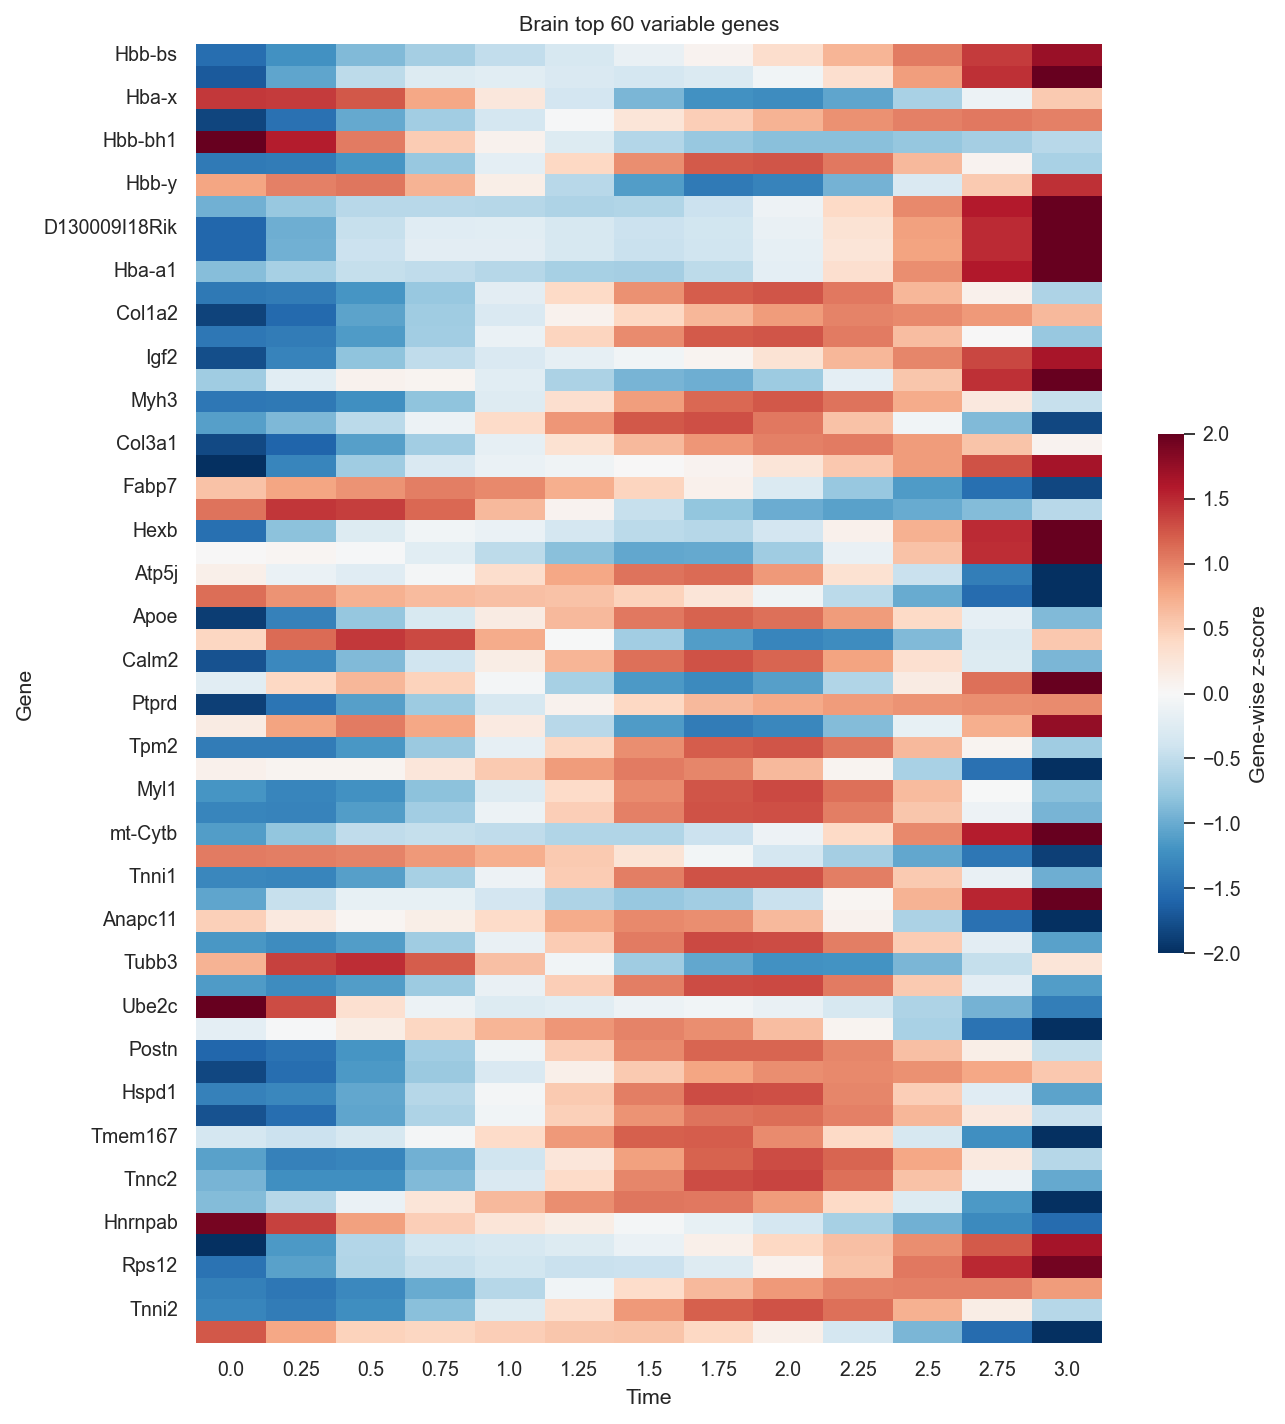

In [6]:
TOP_N = 60
top_genes = top_var_df.sort_values("variance", ascending=False).head(TOP_N)["gene"].tolist()
compact = expr_df.loc[top_genes]
compact_z = compact.sub(compact.mean(axis=1), axis=0).div(compact.std(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(8.5, 9.0))
sns.heatmap(
    compact_z,
    cmap="RdBu_r",
    center=0,
    vmin=-2,
    vmax=2,
    ax=ax,
    cbar_kws={"label": "Gene-wise z-score", "shrink": 0.4},
)
ax.set_title(f"Brain top {TOP_N} variable genes")
ax.set_xlabel("Time")
ax.set_ylabel("Gene")
plt.tight_layout()
save_svg(fig, "brain_top_variable_genes_heatmap")
plt.show()


## Representative gene trends

Plot only the top 12 variable genes so the time trends are readable.


Saved SVG: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/svg/brain_top_variable_gene_trajectories.svg


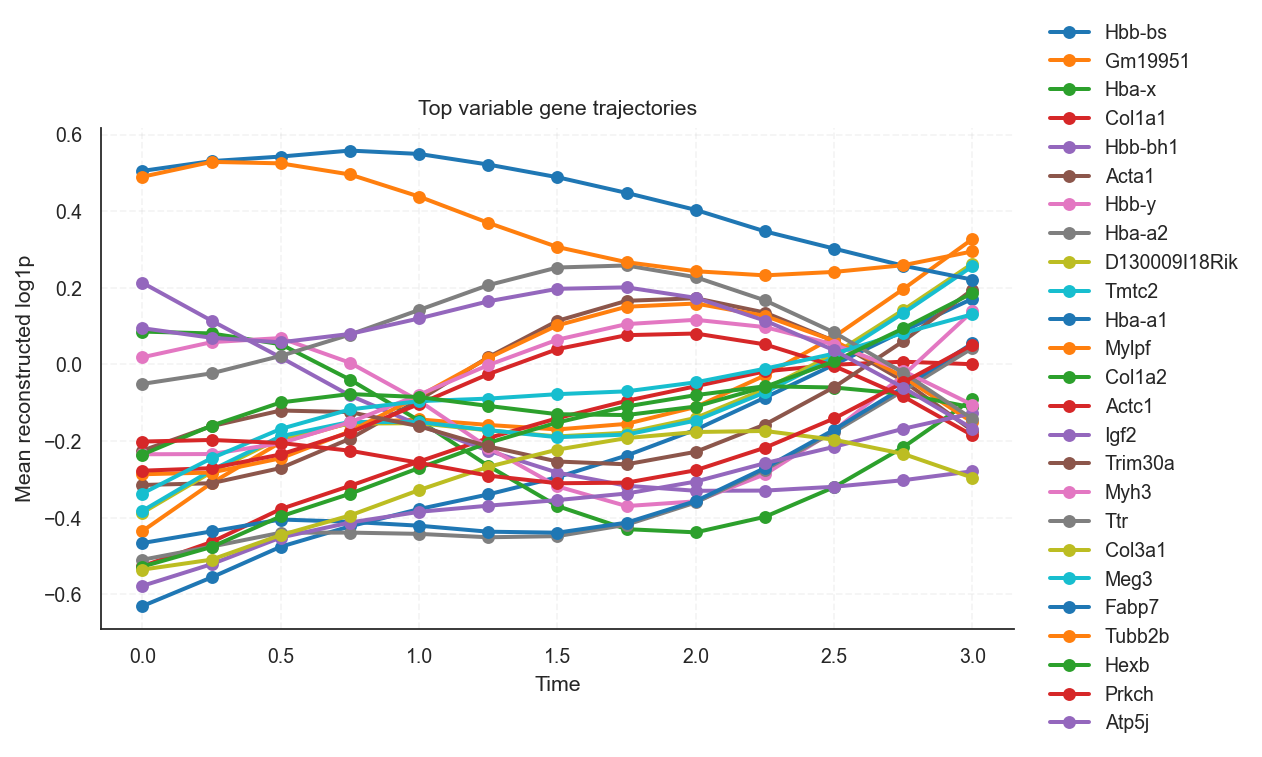

In [7]:
LINE_TOP = 25
line_genes = top_var_df.sort_values("variance", ascending=False).head(LINE_TOP)["gene"].tolist()
fig, ax = plt.subplots(figsize=(8.0, 4.5))
palette = sns.color_palette("tab10", n_colors=len(line_genes))
for color, gene in zip(palette, line_genes):
    ax.plot(expr_df.columns, expr_df.loc[gene], marker="o", linewidth=1.8, color=color, label=gene)
ax.set_title("Top variable gene trajectories")
ax.set_xlabel("Time")
ax.set_ylabel("Mean reconstructed log1p")
ax.grid(True, alpha=0.2, linestyle="--")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
save_svg(fig, "brain_top_variable_gene_trajectories")
plt.show()


## Pattern overview panels

Change `NOTEBOOK_N_CLUSTERS` above to an integer or `'auto'`. This section is only for the pattern panels and their representative genes.


Saved SVG: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/svg/brain_temporal_programs.svg


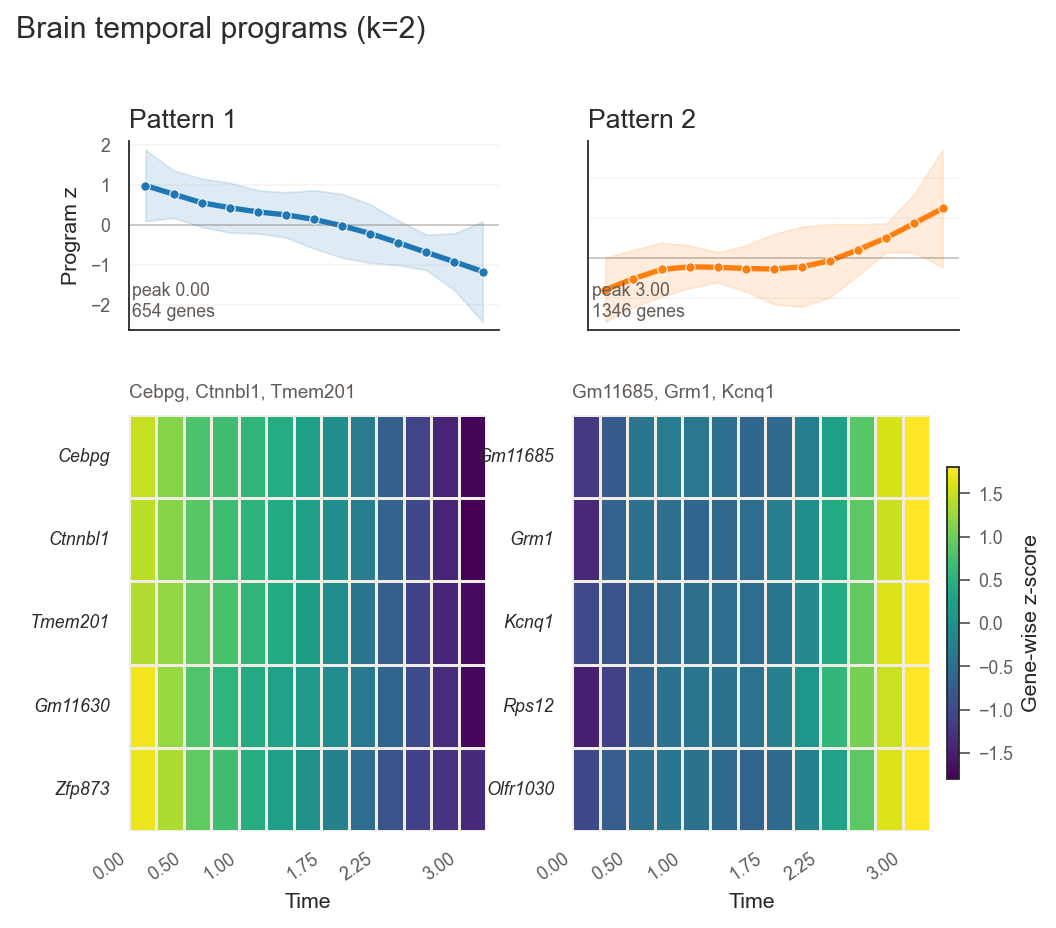

In [8]:
selected_genes, cluster_boundaries, gene_label_positions, cluster_summary_df = select_pattern_genes(
    expr_z_df,
    notebook_assign_df,
    max_per_cluster=PATTERN_GENES_PER_CLUSTER,
    label_top_n=PATTERN_LABEL_TOP_N,
)
representative_df = build_representative_gene_table(expr_z_df, notebook_assign_df, REPRESENTATIVE_GENES_PER_PATTERN)
if representative_df.empty:
    raise ValueError("No representative genes were selected for the notebook figure panels.")

smooth_z_df = smooth_time_df(expr_z_df, DISPLAY_SMOOTH_SIGMA)
time_values = np.asarray(expr_z_df.columns, dtype=float)
pattern_ids = sorted(int(x) for x in notebook_assign_df["cluster"].unique())

fig = plt.figure(figsize=(3.35 * len(pattern_ids), 5.6), facecolor=PANEL_BG)
outer = GridSpec(2, len(pattern_ids), figure=fig, height_ratios=[1.0, 2.2], hspace=0.28, wspace=0.24)
heat_axes = []
for panel_idx, cluster_id in enumerate(pattern_ids):
    color = PATTERN_CLUSTER_COLORS[(cluster_id - 1) % len(PATTERN_CLUSTER_COLORS)]
    curve_sub = notebook_curve_df.loc[notebook_curve_df["cluster"] == cluster_id].sort_values("time")
    mean_s = maybe_gaussian_1d(curve_sub["mean"].to_numpy(dtype=float), DISPLAY_SMOOTH_SIGMA)
    std_s = maybe_gaussian_1d(curve_sub["std"].fillna(0).to_numpy(dtype=float), DISPLAY_SMOOTH_SIGMA)
    ax_top = fig.add_subplot(outer[0, panel_idx])
    ax_top.plot(curve_sub["time"], mean_s, color=color, linewidth=2.4, solid_capstyle="round")
    ax_top.fill_between(curve_sub["time"], mean_s - std_s, mean_s + std_s, color=color, alpha=0.14)
    ax_top.scatter(curve_sub["time"], curve_sub["mean"], color=color, s=18, zorder=3, edgecolor=PANEL_BG, linewidth=0.45)
    ax_top.axhline(0, color=TEXT_MID, linewidth=0.8, alpha=0.32)
    ax_top.set_title(f"Pattern {cluster_id}", loc="left", fontsize=12, color=TEXT_DARK)
    ax_top.set_xlabel("")
    ax_top.set_ylabel("Program z")
    ax_top.set_facecolor(PANEL_BG)
    ax_top.grid(True, axis="y", alpha=0.22, linestyle="-", color=GRID_COLOR)
    if panel_idx > 0:
        ax_top.set_ylabel("")
        ax_top.set_yticklabels([])
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_top.tick_params(axis="y", labelsize=8, colors=TEXT_MID)
    summary_row = cluster_summary_df.loc[cluster_summary_df["cluster"] == cluster_id].iloc[0]
    ax_top.text(0.01, 0.05, f"peak {summary_row['prototype_peak_time']:.2f}\n{summary_row['n_genes_total']} genes", transform=ax_top.transAxes, ha="left", va="bottom", fontsize=8, color=TEXT_MID)

    rep_genes = representative_df.loc[representative_df["cluster"] == cluster_id, "gene"].tolist()
    rep_heat = smooth_z_df.loc[rep_genes]
    rep_heat = rep_heat.assign(_peak=rep_heat.idxmax(axis=1).astype(float)).sort_values(["_peak"], kind="stable").drop(columns="_peak")
    ax_bottom = fig.add_subplot(outer[1, panel_idx])
    sns.heatmap(rep_heat, ax=ax_bottom, cmap=PATTERN_CMAP, center=0, vmin=-PATTERN_VALUE_CLIP, vmax=PATTERN_VALUE_CLIP, cbar=False, linewidths=0.5, linecolor="#f1ece4")
    ax_bottom.set_title(", ".join(rep_heat.index[:3]), fontsize=8.5, loc="left", pad=8, color=TEXT_MID)
    ax_bottom.set_xlabel("Time")
    ax_bottom.set_ylabel("")
    ax_bottom.set_facecolor(PANEL_BG)
    ax_bottom.set_yticklabels(ax_bottom.get_yticklabels(), rotation=0, fontsize=8, fontstyle="italic", color=TEXT_DARK)
    set_sparse_time_ticks(ax_bottom, time_values, max_labels=6, rotation=35)
    ax_bottom.tick_params(axis="x", colors=TEXT_MID)
    heat_axes.append(ax_bottom)

sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=-PATTERN_VALUE_CLIP, vmax=PATTERN_VALUE_CLIP), cmap=PATTERN_CMAP)
cbar = fig.colorbar(sm, ax=heat_axes, fraction=0.015, pad=0.02, aspect=25)
cbar.set_label("Gene-wise z-score")
cbar.ax.tick_params(labelsize=8, colors=TEXT_MID)
fig.suptitle(f"Brain temporal programs (k={notebook_k})", x=0.02, y=1.02, ha="left", fontsize=13.5, color=TEXT_DARK)
save_svg(fig, "brain_temporal_programs")
plt.show()


## Wave Map Preparation

This is independent from the pattern panels above. It first selects the top dynamic genes, orders them by peak time, then performs contiguous phase segmentation along that order.


In [9]:
wave_genes = gene_variance.head(BAND_TOP_GENES).index.tolist()
wave_base_df = smooth_z_df.loc[wave_genes]
wave_peak_meta = pd.DataFrame({
    "gene": wave_base_df.index,
    "peak_time": wave_base_df.idxmax(axis=1).astype(float).to_numpy(),
    "amplitude": (wave_base_df.max(axis=1) - wave_base_df.min(axis=1)).to_numpy(),
})
wave_peak_meta = wave_peak_meta.sort_values(["peak_time", "amplitude", "gene"], ascending=[True, False, True], kind="stable").reset_index(drop=True)
wave_ordered_df = wave_base_df.loc[wave_peak_meta["gene"].tolist()]

wave_labels, wave_k, wave_metrics_df = choose_contiguous_phase_labels(wave_ordered_df, WAVE_MAP_N_PHASES)
wave_assign_df = pd.DataFrame({"gene": wave_ordered_df.index, "cluster": wave_labels})
wave_plot_meta = wave_peak_meta.merge(wave_assign_df, on="gene", how="left")
wave_plot_meta = wave_plot_meta.sort_values(["peak_time", "amplitude", "gene"], ascending=[True, False, True], kind="stable").reset_index(drop=True)
wave_plot_df = wave_ordered_df.loc[wave_plot_meta["gene"].tolist()]
wave_cluster_summary_df = pd.DataFrame([
    {
        "cluster": int(cluster_id),
        "n_genes": int(df_cluster.shape[0]),
        "top_preview": ", ".join(df_cluster["gene"].head(8).tolist()),
        "peak_span": f"{df_cluster['peak_time'].min():.2f} -> {df_cluster['peak_time'].max():.2f}",
    }
    for cluster_id, df_cluster in wave_plot_meta.groupby("cluster")
]).sort_values("cluster").reset_index(drop=True)
display(wave_metrics_df if not wave_metrics_df.empty else pd.DataFrame())
print("wave_map_n_phases_requested:", WAVE_MAP_N_PHASES)
print("wave_map_n_phases_used:", wave_k)
print("wave_map_phase_ids:", sorted(wave_plot_meta["cluster"].unique().tolist()))
display(wave_cluster_summary_df)


,k,objective,mean_segment_size
0,3,4390.336709,333.333333


wave_map_n_phases_requested: 3
wave_map_n_phases_used: 3
wave_map_phase_ids: [1, 2, 3]


,cluster,n_genes,top_preview,peak_span
0,1,365,"Gm45774, Ppbp, Hmbs, Galnt7, Tenm3, Mki67, Cdr...",0.00 -> 1.25
1,2,417,"Upk1b, Pik3r2, Ccdc181, Gpcpd1, Dlk1, Mettl27,...",1.25 -> 2.50
2,3,218,"Gpx1, Selenbp2, Cyp2d26, Cxcl14, Rpl30, Aebp1,...",2.50 -> 3.00


## Developmental Wave Map

This plot uses only the wave-map-specific phase segmentation above. Row order is strictly by peak time; the side annotation shows contiguous phases along that order.


/var/folders/b5/t2zljhrs6vq96hjn5_n9zzz80000gn/T/ipykernel_56197/2549794143.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0.05, 0.0, 1.0, 1.0))


Saved SVG: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/svg/brain_developmental_wave_map.svg


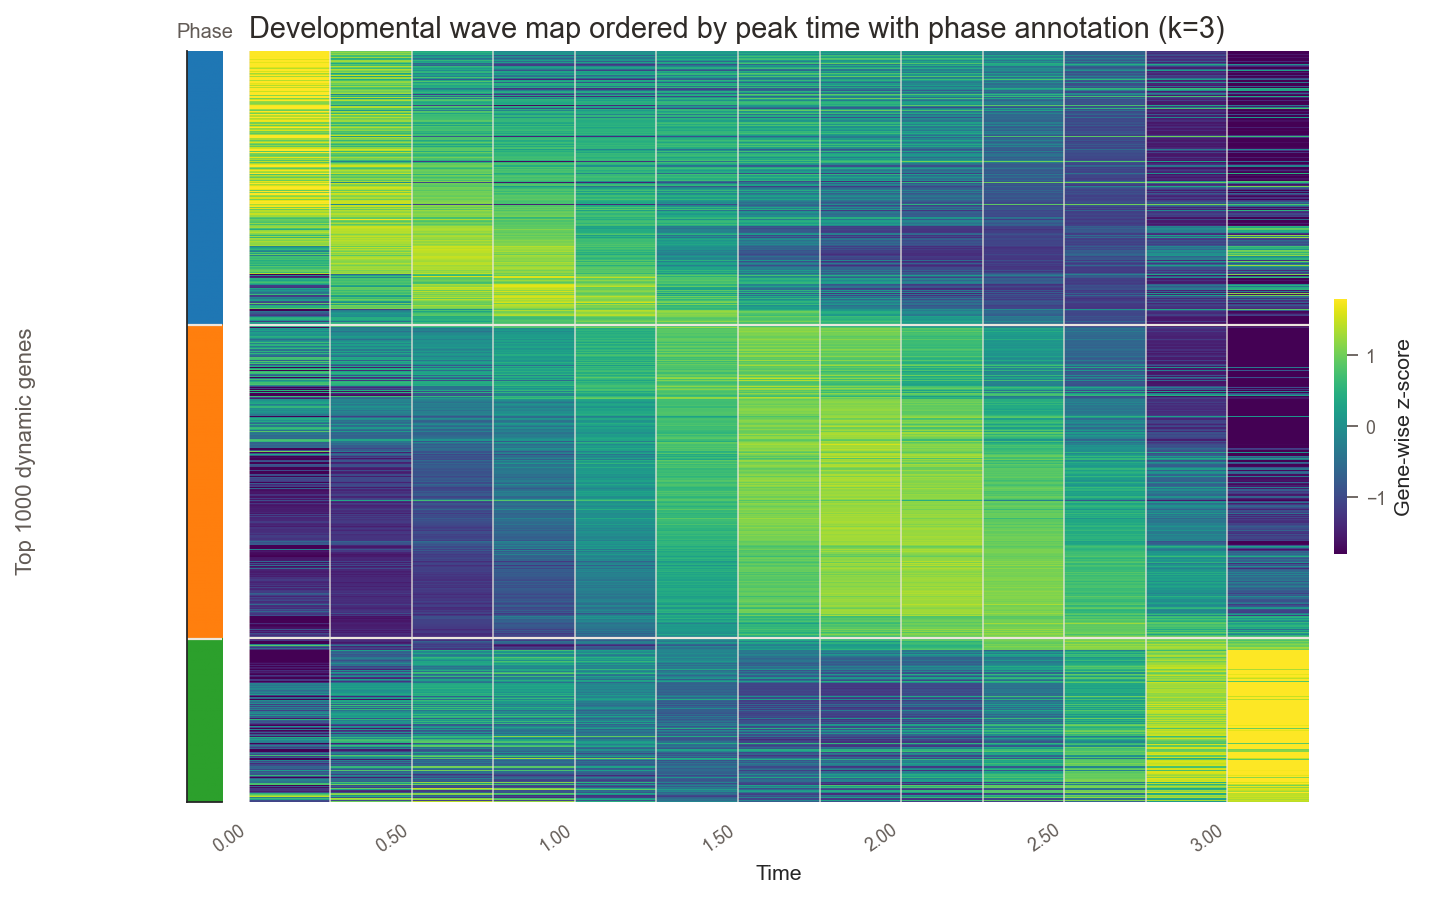

In [10]:
cluster_strip = np.asarray([row - 1 for row in wave_plot_meta["cluster"]], dtype=int).reshape(-1, 1)

fig = plt.figure(figsize=(10.8, 6.1), facecolor=PANEL_BG)
gs = GridSpec(1, 2, figure=fig, width_ratios=[0.28, 10.0], wspace=0.04)
ax_strip = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1])
ax_strip.imshow(cluster_strip, aspect="auto", cmap=ListedColormap([PATTERN_CLUSTER_COLORS[(cid - 1) % len(PATTERN_CLUSTER_COLORS)] for cid in wave_plot_meta["cluster"].unique()]))
ax_strip.set_xticks([])
ax_strip.set_yticks([])
ax_strip.set_title("Phase", fontsize=9, color=TEXT_MID, pad=6)
ax_strip.set_facecolor(PANEL_BG)
sns.heatmap(wave_plot_df, ax=ax, cmap=PATTERN_CMAP, center=0, vmin=-PATTERN_VALUE_CLIP, vmax=PATTERN_VALUE_CLIP, cbar_kws={"shrink": 0.34, "pad": 0.02, "label": "Gene-wise z-score"}, yticklabels=False, linewidths=0.0)
ax.set_title(f"Developmental wave map ordered by peak time with phase annotation (k={wave_k})", loc="left", fontsize=13, color=TEXT_DARK)
ax.set_xlabel("Time")
ax.set_ylabel("")
ax.set_facecolor(PANEL_BG)
fig.text(0.032, 0.47, f"Top {BAND_TOP_GENES} dynamic genes", rotation=90, va="center", ha="center", fontsize=10, color=TEXT_MID)
set_sparse_time_ticks(ax, time_values, max_labels=7, rotation=35)
ax.tick_params(axis="x", colors=TEXT_MID)
for peak_time in sorted(wave_plot_meta["peak_time"].unique()):
    ax.axvline(np.searchsorted(time_values, peak_time), color="#efe9df", linewidth=0.7, alpha=0.8)
phase_starts = [int(sub.index.min()) for _, sub in wave_plot_meta.groupby("cluster", sort=True)]
for boundary in phase_starts[1:]:
    ax.axhline(boundary, color="#ece6dd", linewidth=1.0)
    ax_strip.axhline(boundary, color="#ece6dd", linewidth=1.0)
ax.collections[0].colorbar.ax.tick_params(labelsize=8, colors=TEXT_MID)
plt.tight_layout(rect=(0.05, 0.0, 1.0, 1.0))
save_svg(fig, "brain_developmental_wave_map")
plt.show()


## Pattern curves and pattern gene lists

This is the part you can trust most for your own enrichment: the actual cluster assignments and cluster gene lists.


,cluster,n_genes_total,n_genes_displayed,headline_genes,prototype_peak_time
0,1,654,12,"Cebpg, Ctnnbl1, Tmem201",0.0
1,2,1346,12,"Gm11685, Grm1, Kcnq1",3.0


,cluster,n_genes,top_preview
0,1,654,"1700001C02Rik, 1700016D06Rik, 1700028D13Rik, 1..."
1,2,1346,"0610006L08Rik, 1500009C09Rik, 1600019K03Rik, 1..."


,gene,cluster
0,1700001C02Rik,1
1,1700016D06Rik,1
2,1700028D13Rik,1
3,1700063H04Rik,1
4,1700095J07Rik,1


Saved SVG: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/svg/brain_pattern_level_temporal_curves.svg


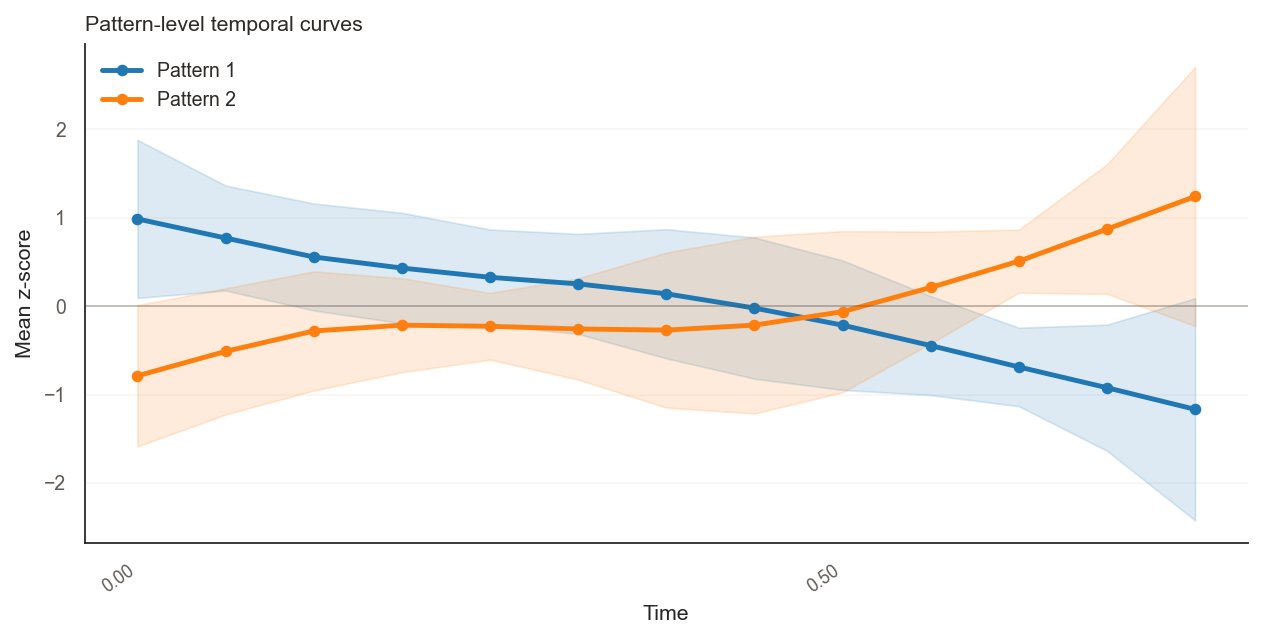

In [11]:
display(cluster_summary_df)
display(cluster_gene_summary_df)
display(notebook_assign_df.head())

fig, ax = plt.subplots(figsize=(8.0, 4.1), facecolor=PANEL_BG)
for cluster_id, sub in notebook_curve_df.groupby("cluster"):
    color = PATTERN_CLUSTER_COLORS[(int(cluster_id) - 1) % len(PATTERN_CLUSTER_COLORS)]
    ax.plot(sub["time"], sub["mean"], marker="o", markersize=4.2, linewidth=2.2, color=color, label=f"Pattern {cluster_id}")
    ax.fill_between(sub["time"], sub["mean"] - sub["std"], sub["mean"] + sub["std"], color=color, alpha=0.15)
ax.set_title("Pattern-level temporal curves", loc="left", color=TEXT_DARK)
ax.set_xlabel("Time")
ax.set_ylabel("Mean z-score")
ax.axhline(0, color=TEXT_MID, linewidth=0.8, alpha=0.4)
ax.set_facecolor(PANEL_BG)
set_sparse_time_ticks(ax, np.asarray(sorted(notebook_curve_df["time"].unique()), dtype=float), max_labels=7, rotation=35)
ax.tick_params(axis="x", colors=TEXT_MID)
ax.tick_params(axis="y", colors=TEXT_MID)
ax.grid(True, axis="y", alpha=0.2, linestyle="-", color=GRID_COLOR)
ax.legend(frameon=False, labelcolor=TEXT_DARK)
plt.tight_layout()
save_svg(fig, "brain_pattern_level_temporal_curves")
plt.show()


In [12]:
for cluster_id, df_cluster in cluster_gene_tables.items():
    print(f"Pattern {cluster_id}: {len(df_cluster)} genes")
    display(df_cluster.head(20))


Pattern 1: 654 genes


,gene
0,1700001C02Rik
1,1700016D06Rik
2,1700028D13Rik
3,1700063H04Rik
4,1700095J07Rik
5,1700109H08Rik
6,2310040G07Rik
7,2900089D17Rik
8,4732414G09Rik
9,4732471J01Rik


Pattern 2: 1346 genes


,gene
0,0610006L08Rik
1,1500009C09Rik
2,1600019K03Rik
3,1700003P14Rik
4,1700008P02Rik
5,1700011C11Rik
6,1700011H14Rik
7,1700012B07Rik
8,1700012J15Rik
9,1700013H16Rik


## Export gene lists for your own enrichment

This cell writes plain text gene lists, one file per pattern, so you can paste them into any enrichment tool you prefer.


In [13]:
manual_dir = RESULT_DIR / "manual_enrichment_inputs"
manual_dir.mkdir(exist_ok=True)

export_rows = []
for cluster_id, df_cluster in cluster_gene_tables.items():
    genes = df_cluster["gene"].astype(str).tolist()
    out_txt = manual_dir / f"brain_pattern_{cluster_id}_genes.txt"
    out_txt.write_text("\n".join(genes) + "\n", encoding="utf-8")
    export_rows.append({"group_type": "pattern", "group_id": int(cluster_id), "path": str(out_txt), "n_genes": int(len(genes))})
    print(out_txt, len(genes))

for phase_id, df_phase in wave_plot_meta.groupby("cluster", sort=True):
    genes = df_phase["gene"].astype(str).tolist()
    out_txt = manual_dir / f"brain_wave_phase_{int(phase_id)}_genes.txt"
    out_txt.write_text("\n".join(genes) + "\n", encoding="utf-8")
    export_rows.append({"group_type": "wave_phase", "group_id": int(phase_id), "path": str(out_txt), "n_genes": int(len(genes))})
    print(out_txt, len(genes))

export_summary_df = pd.DataFrame(export_rows).sort_values(["group_type", "group_id"]).reset_index(drop=True)
display(export_summary_df)


/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/manual_enrichment_inputs/brain_pattern_1_genes.txt 654
/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/manual_enrichment_inputs/brain_pattern_2_genes.txt 1346
/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/manual_enrichment_inputs/brain_wave_phase_1_genes.txt 365
/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/manual_enrichment_inputs/brain_wave_phase_2_genes.txt 417
/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/manual_enrichment_inputs/brain_wave_phase_3_genes.txt 218


,group_type,group_id,path,n_genes
0,pattern,1,/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/...,654
1,pattern,2,/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/...,1346
2,wave_phase,1,/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/...,365
3,wave_phase,2,/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/...,417
4,wave_phase,3,/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/...,218


## Optional: inspect the saved pathway tables

These are just the script outputs. If you do not trust them, ignore this section and use the exported plain text gene lists above.


In [14]:
if int(notebook_k) != int(manifest['n_clusters']):
    print('Notebook cluster count differs from the exported script cluster count, so the saved pathway tables are not directly comparable.')
else:
    for cluster_id in sorted(notebook_assign_df['cluster'].unique()):
        pw_path = TABLE_DIR / f"brain_pathway_cluster_{cluster_id}.csv"
        if not pw_path.exists():
            continue
        df_pw = pd.read_csv(pw_path)
        print(f"Pattern {cluster_id} pathway table")
        display(df_pw.head(10))


Pattern 1 pathway table


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,Cluster
0,KEGG_2019_Mouse.gmt,"Glycine, serine and threonine metabolism",5/40,0.002352,0.304545,6.522339,39.477216,ALAS2;PSAT1;AOC2;PIPOX;BPGM,1
1,KEGG_2019_Mouse.gmt,Ubiquitin mediated proteolysis,10/138,0.001551,0.304545,3.489848,22.575990,CUL7;UBE2L6;UBE2O;ERCC8;UBR5;UBE2C;ANAPC11;FBX...,1
2,KEGG_2019_Mouse.gmt,Axon guidance,11/180,0.003541,0.305719,2.898272,16.355830,BOC;EPHB3;CXCL12;SEMA6C;ARHGEF12;PARD6G;DCC;PI...,1
3,KEGG_2019_Mouse.gmt,Signaling pathways regulating pluripotency of ...,9/137,0.005077,0.328755,3.141164,16.594698,DVL2;HNF1A;HOXB1;OTX1;FZD7;PIK3R2;ZIC3;WNT3A;ID4,1
4,KEGG_2019_Mouse.gmt,Colorectal cancer,6/88,0.017605,0.573949,3.314905,13.390837,SOS2;MLH1;PIK3R2;DCC;APPL1;ARAF,1


Pattern 2 pathway table


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,Cluster
0,KEGG_2019_Mouse.gmt,Complement and coagulation cascades,24/88,2.641135e-13,6.470781e-11,8.689288,251.662623,PLG;F10;VTN;SERPINA1C;C4B;F7;C3;F13B;HC;SERPIN...,2
1,KEGG_2019_Mouse.gmt,Protein digestion and absorption,19/90,9.384724e-09,1.149629e-06,6.146795,113.618477,COL11A2;COL2A1;COL3A1;COL6A4;COL14A1;COL1A1;EL...,2
2,KEGG_2019_Mouse.gmt,ECM-receptor interaction,18/83,1.480249e-08,1.208870e-06,6.352807,114.531399,IBSP;COL2A1;COL1A1;COL9A2;LAMB2;LAMA3;LAMA4;CO...,2
3,KEGG_2019_Mouse.gmt,African trypanosomiasis,10/39,5.090400e-06,3.117870e-04,7.866730,95.880912,APOA1;KNG1;LAMA4;NPPA;PRKCB;HBA-A1;PLCB2;HBB-B...,2
4,KEGG_2019_Mouse.gmt,Inflammatory mediator regulation of TRP channels,16/127,1.409497e-04,6.906535e-03,3.291325,29.184534,TRPV2;CYP2C70;KNG1;CALM2;CYP4A12A;CALM4;ASIC5;...,2


## Next steps

- If the heatmap is still too long, reduce `TOP_N` from 60 to 30.
- Re-run the script with `--n-clusters auto` and re-open this notebook to compare cluster selection metrics.
- Use `manual_enrichment_inputs/brain_pattern_*_genes.txt` for your own enrichment workflow.
